# Training Baseline U-Net dan ProCANet

Notebook ini hanya orkestrasi eksekusi. Training, dataset loader, model, loss, metrik, checkpoint, dan early stopping tetap memakai kode repo: `scripts/train_segmentation.py` dan modul `training/`.

## 1. Setup

In [6]:
from __future__ import annotations

import csv
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from scripts.train_segmentation import resolve_device
from training.datasets import FloodTileDataset

PROJECT_ROOT = Path.cwd()
TILE_ROOT = PROJECT_ROOT / "dataset" / "tiles"
RUNS_ROOT = PROJECT_ROOT / "runs"
DEVICE = resolve_device("auto")

print(f"Project root: {PROJECT_ROOT}")
print(f"Tile root: {TILE_ROOT}")
print(f"Device: {DEVICE}")
print(f"Torch: {torch.__version__}")

Project root: /home/nozomi/Productive/skripsi
Tile root: /home/nozomi/Productive/skripsi/dataset/tiles
Device: cuda
Torch: 2.12.0+cu130


## 2. Cek split dataset

In [7]:
def count_tiles(architecture: str) -> dict[str, int]:
    return {
        split: len(FloodTileDataset(split, architecture=architecture, root=TILE_ROOT, augment=False))
        for split in ("train", "val", "test")
    }

tile_counts = {
    "unet": count_tiles("unet"),
    "procanet": count_tiles("procanet"),
}
tile_counts

{'unet': {'train': 983, 'val': 36, 'test': 102},
 'procanet': {'train': 983, 'val': 36, 'test': 102}}

## 3. Konfigurasi eksperimen

In [8]:
COMMON_ARGS = {
    "epochs": 50,
    "batch_size": 4,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "num_workers": 0,
    "base_channels": 32,
    "early_stopping_patience": 5,
    "early_stopping_min_delta": 0.0,
    # Untuk smoke test cepat, isi angka kecil, contoh: 2.
    # Untuk training penuh, biarkan None.
    "max_batches": None,
}

EXPERIMENTS = [
    # {
    #     "name": "baseline_unet",
    #     "architecture": "unet",
    #     "output_dir": RUNS_ROOT / "baseline_unet",
    # },
    {
        "name": "procanet",
        "architecture": "procanet",
        "output_dir": RUNS_ROOT / "procanet",
    },
]

COMMON_ARGS, EXPERIMENTS

({'epochs': 50,
  'batch_size': 4,
  'lr': 0.0001,
  'weight_decay': 0.0001,
  'num_workers': 0,
  'base_channels': 32,
  'early_stopping_patience': 5,
  'early_stopping_min_delta': 0.0,
  'max_batches': None},
 [{'name': 'procanet',
   'architecture': 'procanet',
   'output_dir': PosixPath('/home/nozomi/Productive/skripsi/runs/procanet')}])

## 4. Fungsi eksekusi training

In [9]:
def build_train_command(experiment: dict, common_args: dict) -> list[str]:
    cmd = [
        "uv",
        "run",
        "python",
        "-m",
        "scripts.train_segmentation",
        "--architecture",
        experiment["architecture"],
        "--epochs",
        str(common_args["epochs"]),
        "--batch-size",
        str(common_args["batch_size"]),
        "--lr",
        str(common_args["lr"]),
        "--weight-decay",
        str(common_args["weight_decay"]),
        "--num-workers",
        str(common_args["num_workers"]),
        "--device",
        "auto",
        "--output-dir",
        str(experiment["output_dir"]),
        "--tile-root",
        str(TILE_ROOT),
        "--base-channels",
        str(common_args["base_channels"]),
        "--early-stopping-patience",
        str(common_args["early_stopping_patience"]),
        "--early-stopping-min-delta",
        str(common_args["early_stopping_min_delta"]),
    ]
    if common_args["max_batches"] is not None:
        cmd.extend(["--max-batches", str(common_args["max_batches"])])
    return cmd


def run_training(experiment: dict, common_args: dict = COMMON_ARGS) -> None:
    experiment["output_dir"].mkdir(parents=True, exist_ok=True)
    cmd = build_train_command(experiment, common_args)
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)


def run_all_experiments() -> None:
    for experiment in EXPERIMENTS:
        print(f"\n=== Training {experiment['name']} ===")
        run_training(experiment)

## 5. Jalankan training

Cell ini menjalankan:

- baseline U-Net pada split `train`, validasi split `val`
- ProCANet dua encoder pada split `train`, validasi split `val`
- checkpoint terbaik `best.pt`
- log training `metrics.csv`
- konfigurasi eksperimen `config.json`

In [10]:
run_all_experiments()


=== Training procanet ===
uv run python -m scripts.train_segmentation --architecture procanet --epochs 50 --batch-size 4 --lr 0.0001 --weight-decay 0.0001 --num-workers 0 --device auto --output-dir /home/nozomi/Productive/skripsi/runs/procanet --tile-root /home/nozomi/Productive/skripsi/dataset/tiles --base-channels 32 --early-stopping-patience 5 --early-stopping-min-delta 0.0


procanet epoch 2/50 train:   0%|                       | 0/246 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.1589374316901695, 'train_iou': 0.3525330850201251, 'train_dice': 0.5212931039167586, 'val_loss': 1.0655426118108962, 'val_iou': 0.4817294647936633, 'val_dice': 0.6502259369739213, 'best_val_iou': 0.4817294647936633, 'saved': 1, 'bad_epochs': 0, 'stopped_early': 0}


procanet epoch 2/50 val: 100%|███████████████████| 9/9 [00:02<00:00,  3.79it/s]


{'epoch': 2, 'train_loss': 1.0184615101756118, 'train_iou': 0.5107818354867144, 'train_dice': 0.6761821243663028, 'val_loss': 0.9502113792631361, 'val_iou': 0.5651720017275688, 'val_dice': 0.7221851670024209, 'best_val_iou': 0.5651720017275688, 'saved': 1, 'bad_epochs': 0, 'stopped_early': 0}


...

{'epoch': 15, 'train_loss': 0.5641237048477661, 'train_iou': 0.6017374003913365, 'train_dice': 0.7513558717481655, 'val_loss': 0.6982285992966758, 'val_iou': 0.5560146912319511, 'val_dice': 0.7146650920008152, 'best_val_iou': 0.6224360219310695, 'saved': 0, 'bad_epochs': 3, 'stopped_early': 0}


procanet epoch 17/50 train:   0%|                      | 0/246 [00:00<?, ?it/s]

{'epoch': 16, 'train_loss': 0.5618940034532934, 'train_iou': 0.6004250620493735, 'train_dice': 0.7503319915279485, 'val_loss': 0.6494660692082511, 'val_iou': 0.6212325968760803, 'val_dice': 0.7663707207381848, 'best_val_iou': 0.6224360219310695, 'saved': 0, 'bad_epochs': 4, 'stopped_early': 0}


procanet epoch 17/50 val: 100%|██████████████████| 9/9 [00:02<00:00,  3.91it/s]


{'epoch': 17, 'train_loss': 0.5814343685117679, 'train_iou': 0.6036180717716071, 'train_dice': 0.7528202411747035, 'val_loss': 0.6572887334558699, 'val_iou': 0.6146177241221251, 'val_dice': 0.7613167066604518, 'best_val_iou': 0.6224360219310695, 'saved': 0, 'bad_epochs': 5, 'stopped_early': 1}


## 6. Baca log training

In [11]:
def read_metrics(path: Path) -> list[dict[str, float | int | bool]]:
    rows = []
    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            parsed = {
                "epoch": int(row["epoch"]),
                "train_loss": float(row["train_loss"]),
                "train_iou": float(row["train_iou"]),
                "train_dice": float(row["train_dice"]),
                "val_loss": float(row["val_loss"]),
                "val_iou": float(row["val_iou"]),
                "val_dice": float(row["val_dice"]),
                "best_val_iou": float(row["best_val_iou"]),
                "saved": bool(int(row["saved"])),
                "bad_epochs": int(row["bad_epochs"]),
                "stopped_early": bool(int(row["stopped_early"])),
            }
            rows.append(parsed)
    return rows


metrics = {
    experiment["name"]: read_metrics(experiment["output_dir"] / "metrics.csv")
    for experiment in EXPERIMENTS
}

summary = {
    name: {
        "epochs_ran": len(rows),
        "best_val_iou": max(row["val_iou"] for row in rows),
        "best_val_dice": max(row["val_dice"] for row in rows),
    }
    for name, rows in metrics.items()
}
summary

{'procanet': {'epochs_ran': 17,
  'best_val_iou': 0.6224360219310695,
  'best_val_dice': 0.7672857524332188}}

## 7. Plot dan simpan grafik

PosixPath('/home/nozomi/Productive/skripsi/runs/training_curves.png')

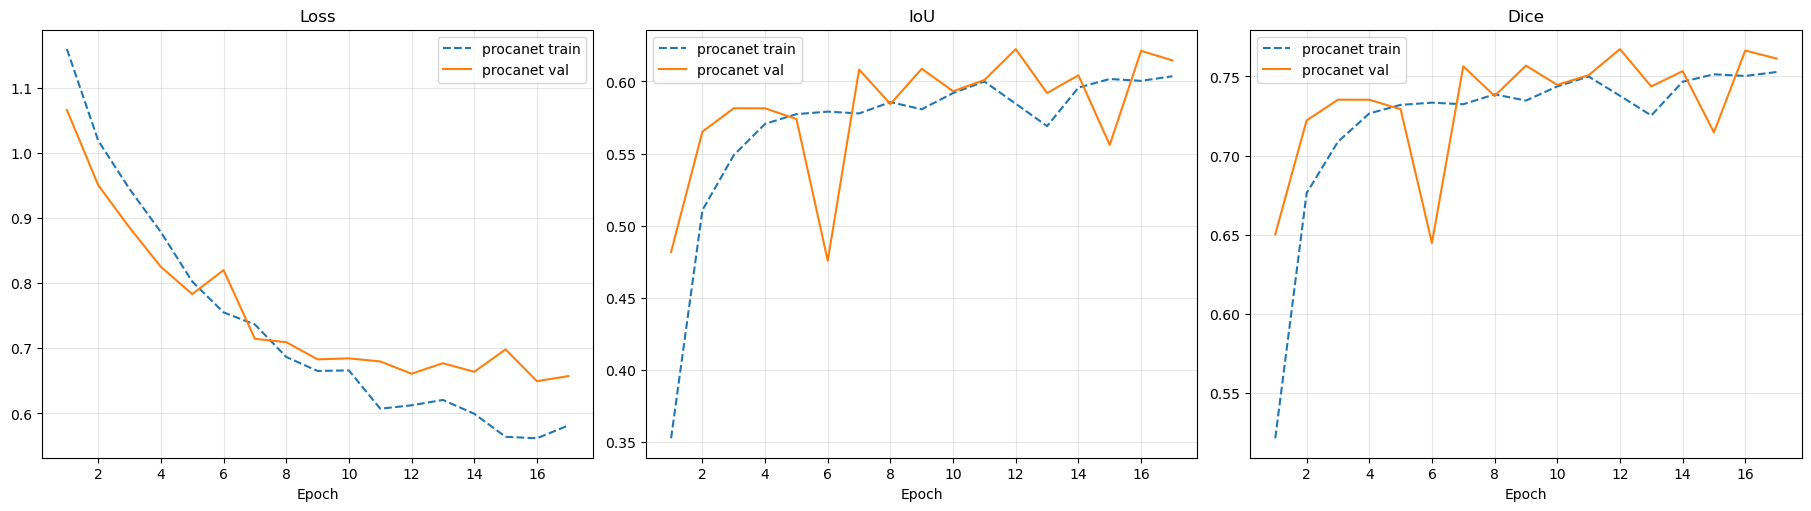

In [12]:
def plot_training_curves(metrics: dict[str, list[dict]]) -> Path:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    specs = [
        ("loss", "Loss", "train_loss", "val_loss"),
        ("iou", "IoU", "train_iou", "val_iou"),
        ("dice", "Dice", "train_dice", "val_dice"),
    ]
    for ax, (_, title, train_key, val_key) in zip(axes, specs):
        for name, rows in metrics.items():
            epochs = [row["epoch"] for row in rows]
            ax.plot(epochs, [row[train_key] for row in rows], linestyle="--", label=f"{name} train")
            ax.plot(epochs, [row[val_key] for row in rows], label=f"{name} val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        ax.legend()

    RUNS_ROOT.mkdir(parents=True, exist_ok=True)
    output_path = RUNS_ROOT / "training_curves.png"
    fig.savefig(output_path, dpi=160)
    return output_path


plot_path = plot_training_curves(metrics)
plot_path

## 8. Cek output wajib

In [13]:
required_outputs = []
for experiment in EXPERIMENTS:
    output_dir = experiment["output_dir"]
    required_outputs.extend([
        output_dir / "best.pt",
        output_dir / "metrics.csv",
        output_dir / "config.json",
    ])
required_outputs.append(RUNS_ROOT / "training_curves.png")

missing = [path for path in required_outputs if not path.exists()]
if missing:
    raise FileNotFoundError("Missing outputs: " + ", ".join(str(path) for path in missing))

for path in required_outputs:
    print(path)

/home/nozomi/Productive/skripsi/runs/procanet/best.pt
/home/nozomi/Productive/skripsi/runs/procanet/metrics.csv
/home/nozomi/Productive/skripsi/runs/procanet/config.json
/home/nozomi/Productive/skripsi/runs/training_curves.png
